### Kaggle Dataset Download and Setup

This section handles the setup for downloading the Kaggle dataset, including credentials and the download/extraction process.

In [12]:
# Set up Kaggle API credentials
# The 'kaggle (2).json' file needs to be present in /content/
!mkdir -p ~/.kaggle
!cp "/content/kaggle (2).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API credentials set up successfully.")

Kaggle API credentials set up successfully.


In [66]:
import os

# Download a Kaggle dataset
# Using 'paultimothymooney/chest-xray-pneumonia' as an example
print("Downloading chest-xray-pneumonia dataset...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Determine the zip file name based on the dataset ID
zip_file_name = 'chest-xray-pneumonia.zip'

if os.path.exists(zip_file_name):
    print(f"Dataset '{zip_file_name}' downloaded successfully.")
else:
    print(f"ERROR: Dataset '{zip_file_name}' not found after download attempt. Please check your Kaggle API credentials, dataset permissions, and the exact dataset ID.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:29<00:00, 84.2MB/s]

Dataset 'chest-xray-pneumonia.zip' downloaded successfully.


In [67]:
import os

# Unzip the downloaded dataset into a dedicated directory
print("Extracting chest-xray-pneumonia dataset...")
zip_file_name = 'chest-xray-pneumonia.zip' # Make sure this matches the downloaded zip name
extract_dir = 'chest_xray_dataset' # Dedicated directory for this dataset

if os.path.exists(zip_file_name):
    # Create extraction directory if it doesn't exist
    os.makedirs(extract_dir, exist_ok=True)
    !unzip -q {zip_file_name} -d {extract_dir}
    if os.path.isdir(extract_dir):
        print(f"Dataset extracted to '{extract_dir}/'")
    else:
        print(f"ERROR: Extraction failed. Directory '{extract_dir}' was not created. Check zip content and permissions.")
else:
    print(f"Skipping extraction: '{zip_file_name}' not found. Please ensure the dataset was downloaded successfully.")

Extracting chest-xray-pneumonia dataset...
Dataset extracted to 'chest_xray_dataset/'


### Computer Vision: Data Exploration

Now that the dataset is downloaded and extracted, let's explore its structure and visualize some sample images.

In [68]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Update data_dir to point to the newly extracted chest X-ray dataset
data_dir = 'chest_xray_dataset'

# List the contents of the extracted dataset directory to understand its structure
print(f"\nContents of the dataset directory '{data_dir}':")
!ls -R "{data_dir}"

Streaming output truncated to the last 5000 lines.
NORMAL2-IM-0388-0001.jpeg	NORMAL2-IM-1293-0001.jpeg
NORMAL2-IM-0389-0001.jpeg	NORMAL2-IM-1294-0001-0001.jpeg
NORMAL2-IM-0390-0001.jpeg	NORMAL2-IM-1294-0001-0002.jpeg
NORMAL2-IM-0391-0001.jpeg	NORMAL2-IM-1294-0001.jpeg
NORMAL2-IM-0392-0001.jpeg	NORMAL2-IM-1295-0001.jpeg
NORMAL2-IM-0393-0001.jpeg	NORMAL2-IM-1296-0001.jpeg
NORMAL2-IM-0394-0001.jpeg	NORMAL2-IM-1300-0001.jpeg
NORMAL2-IM-0395-0001-0001.jpeg	NORMAL2-IM-1301-0001.jpeg
NORMAL2-IM-0395-0001-0002.jpeg	NORMAL2-IM-1302-0001.jpeg
NORMAL2-IM-0395-0001.jpeg	NORMAL2-IM-1303-0001.jpeg
NORMAL2-IM-0396-0001.jpeg	NORMAL2-IM-1304-0001.jpeg
NORMAL2-IM-0397-0001.jpeg	NORMAL2-IM-1305-0001.jpeg
NORMAL2-IM-0399-0001.jpeg	NORMAL2-IM-1306-0001.jpeg
NORMAL2-IM-0401-0001.jpeg	NORMAL2-IM-1307-0001.jpeg
NORMAL2-IM-0402-0001.jpeg	NORMAL2-IM-1308-0001.jpeg
NORMAL2-IM-0403-0001.jpeg	NORMAL2-IM-1310-0001.jpeg
NORMAL2-IM-0404-0001.jpeg	NORMAL2-IM-1311-0001.jpeg
NORMAL2-IM-0406-0001.jpeg	NORMAL2-IM-1314-000


Attempting to display sample images from various subdirectories:
Displaying from: archive_extracted/bone fracture detection.v4-v4.yolov8/test/images


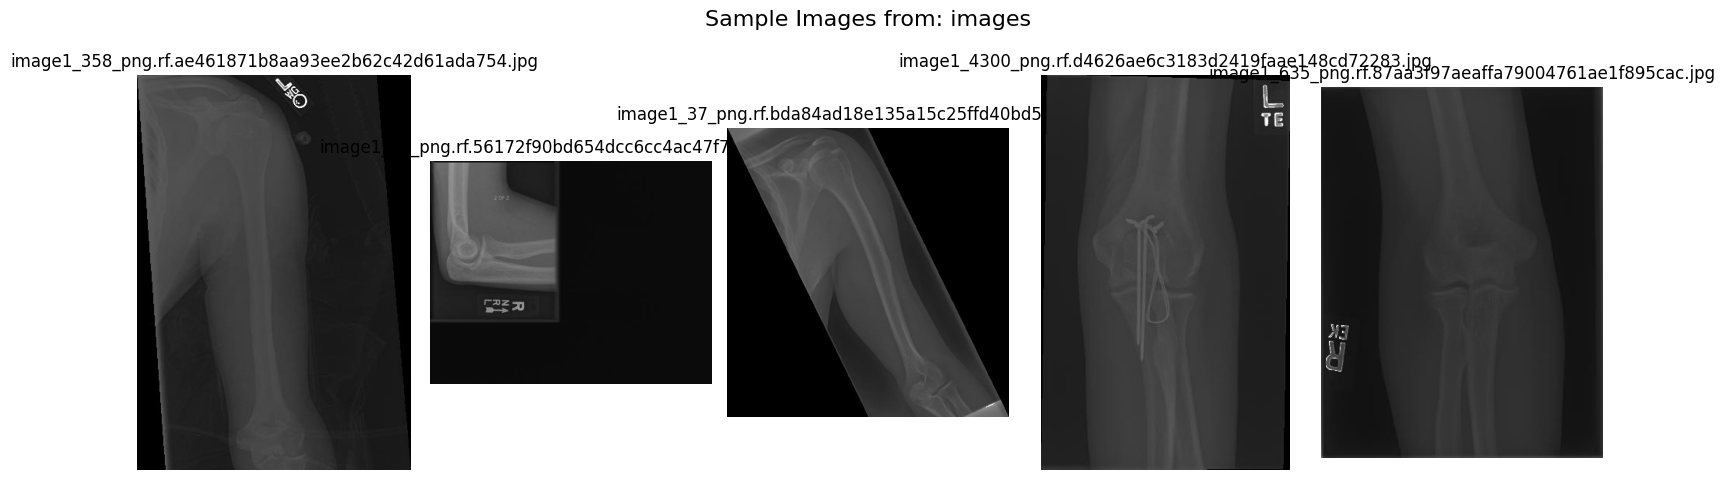

Displaying from: archive_extracted/bone fracture detection.v4-v4.yolov8/train/images


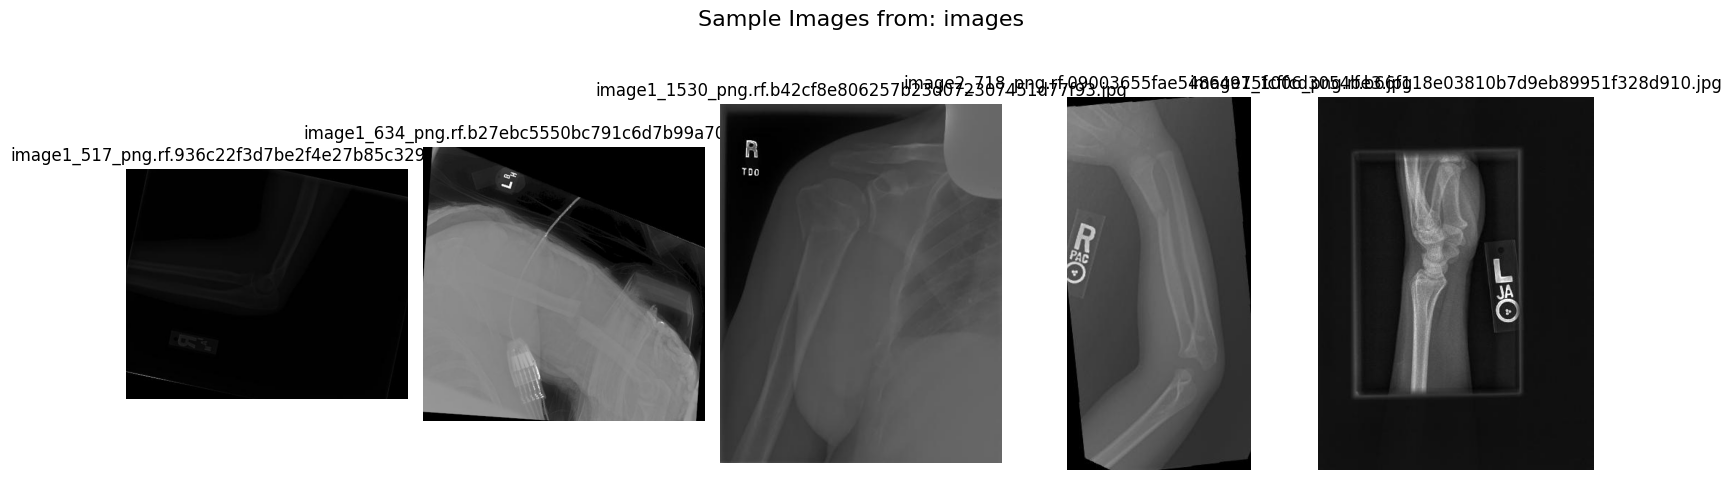

Displaying from: archive_extracted/bone fracture detection.v4-v4.yolov8/valid/images


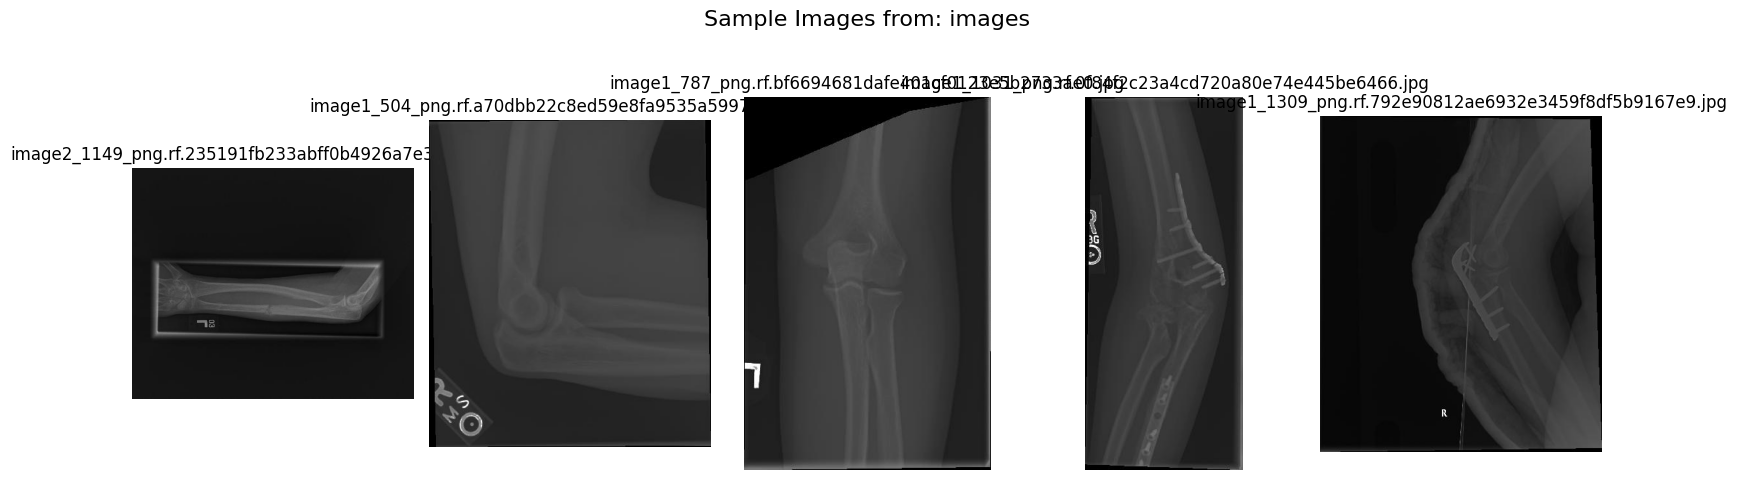

In [29]:
# Function to display a few images from a given directory
def display_sample_images(directory, num_images=5):
    image_files = [f for f in os.listdir(directory) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not image_files:
        print(f"No image files found in {directory}")
        return

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"Sample Images from: {os.path.basename(directory)}", fontsize=16)
    for i, img_file in enumerate(image_files[:num_images]):
        img_path = os.path.join(directory, img_file)
        try:
            img = mpimg.imread(img_path)
            plt.subplot(1, num_images, i + 1)
            plt.imshow(img, cmap='gray') # X-rays are usually grayscale
            plt.title(os.path.basename(img_file))
            plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_file}: {e}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle from overlapping
    plt.show()

# Try to find directories containing images within the extracted dataset
image_directories = []
for root, dirs, files in os.walk(data_dir):
    if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files):
        image_directories.append(root)

print("\nAttempting to display sample images from various subdirectories:")
if not image_directories:
    print(f"No image-containing directories found within {data_dir}. Please check the dataset structure.")
else:
    # Display samples from a few distinct image directories, e.g., train/NORMAL, train/FRACTURE
    unique_image_directories_to_display = sorted(list(set(image_directories)))
    for i, img_dir in enumerate(unique_image_directories_to_display[:3]): # Display from up to 3 distinct directories
        print(f"Displaying from: {img_dir}")
        display_sample_images(img_dir)



### Convolutional Neural Network (CNN) Model Definition

Now that we've explored the dataset, let's define a basic Convolutional Neural Network (CNN) model using TensorFlow/Keras. This model will be structured for image classification, aiming to identify bone fractures from X-ray images.

In [37]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Define the CNN model architecture
def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten the output to feed into a Dense layer
        layers.Flatten(),

        # Dense layers for classification
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Dropout for regularization
        layers.Dense(1, activation='sigmoid') # Output layer for binary classification
    ])
    return model


### Data Loading and Preprocessing for CNN Training

Before we can compile and train the model, we need to load the image data, preprocess it to a suitable format (e.g., resize, normalize), and create batches for efficient training.

In [38]:
import tensorflow as tf

# Define image parameters
IMAGE_SIZE = (128, 128)  # Assuming X-ray images will be resized to 128x128
BATCH_SIZE = 32          # Standard batch size

# Determine input shape and number of classes
# Assuming grayscale images for X-rays (1 channel)
input_shape = (*IMAGE_SIZE, 1)
# Assuming binary classification (fracture/no fracture)
num_classes = 1 # Changed to 1 for binary classification consistency

print(f"Model Input Shape: {input_shape}")
print(f"Number of Classes: {num_classes}")

# Create an instance of the CNN model
model = create_cnn_model(input_shape, num_classes)
model.summary()

Model Input Shape: (128, 128, 1)
Number of Classes: 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

### Recurrent Neural Network (RNN) Example

This section demonstrates a simple Recurrent Neural Network (RNN) using an LSTM layer for sequence prediction. We'll generate some synthetic sequential data, define an LSTM model, and then train and evaluate it.

Training data shape: X=(1000, 50, 1), y=(1000, 1)
Test data shape: X=(200, 50, 1), y=(200, 1)


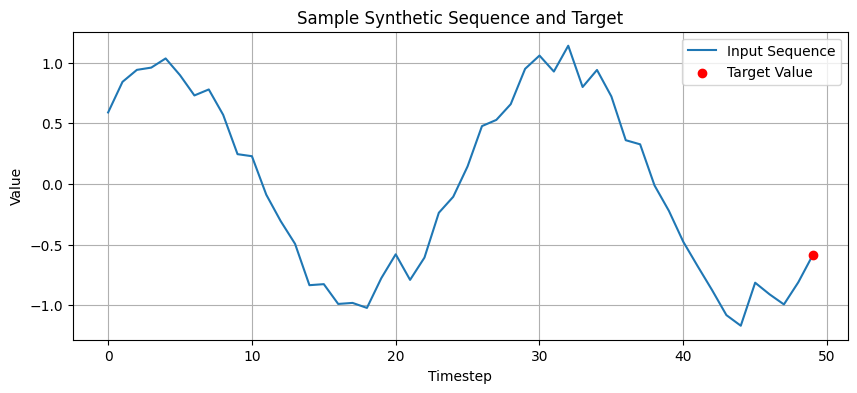

In [54]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# --- 1. Generate Synthetic Sequence Data ---
# Let's create a simple sine wave sequence for demonstration
def generate_sequence_data(num_samples, timesteps, input_dim, noise_strength=0.1):
    X = np.zeros((num_samples, timesteps, input_dim))
    y = np.zeros((num_samples, 1))

    for i in range(num_samples):
        start_phase = np.random.rand() * np.pi * 2
        freq = np.random.rand() * 2 + 0.5 # Frequency between 0.5 and 2.5

        # Input sequence (sine wave)
        t = np.linspace(start_phase, start_phase + timesteps * 0.1 * freq, timesteps)
        X[i, :, 0] = np.sin(t) + np.random.randn(timesteps) * noise_strength

        # Target: value at the next timestep (or some other target, e.g., sum of sequence)
        # For simplicity, let's predict the last value of the sequence as a regression task
        y[i, 0] = X[i, -1, 0]

    return X, y

num_samples = 1000
timesteps = 50
input_dim = 1 # We have one feature (sine wave value)

X_train, y_train = generate_sequence_data(num_samples, timesteps, input_dim)
X_test, y_test = generate_sequence_data(num_samples // 5, timesteps, input_dim)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test data shape: X={X_test.shape}, y={y_test.shape}")

# Visualize a sample sequence
plt.figure(figsize=(10, 4))
plt.plot(X_train[0, :, 0], label='Input Sequence')
plt.scatter(timesteps - 1, y_train[0, 0], color='red', zorder=5, label='Target Value')
plt.title('Sample Synthetic Sequence and Target')
plt.xlabel('Timestep')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Define the RNN Model

Now, let's define a simple RNN model using an LSTM layer. LSTM (Long Short-Term Memory) is a type of recurrent neural network capable of learning long-term dependencies in sequences. We'll use a single LSTM layer followed by a Dense layer for output.

In [55]:
# --- 2. Define the RNN Model Architecture ---
def create_rnn_model(timesteps, input_dim):
    model = models.Sequential([
        layers.LSTM(units=64, input_shape=(timesteps, input_dim)), # LSTM layer
        layers.Dense(1) # Output layer for regression (predicting a single value)
    ])
    return model

rnn_model = create_rnn_model(timesteps, input_dim)
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

### Compile and Train the RNN Model

We'll compile the RNN model using the Adam optimizer and Mean Squared Error (MSE) loss, as this is a regression task (predicting a continuous value). Then, we'll train it on our synthetic data.

Training RNN model...
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - loss: 0.4725 - mae: 0.6010 - val_loss: 0.2164 - val_mae: 0.4164
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.1029 - mae: 0.2637 - val_loss: 0.0409 - val_mae: 0.1628
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0251 - mae: 0.1265 - val_loss: 0.0170 - val_mae: 0.1033
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0149 - mae: 0.0966 - val_loss: 0.0137 - val_mae: 0.0949
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0130 - mae: 0.0900 - val_loss: 0.0114 - val_mae: 0.0856
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0117 - mae: 0.0854 - val_loss: 0.0108 - val_mae: 0.0834
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0092 - mae: 0.0755 - val_loss: 0.0075 - val_mae: 0.0693
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0088 - mae: 0.0743 - val_loss: 0.0096 - val_mae: 0.0813
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2

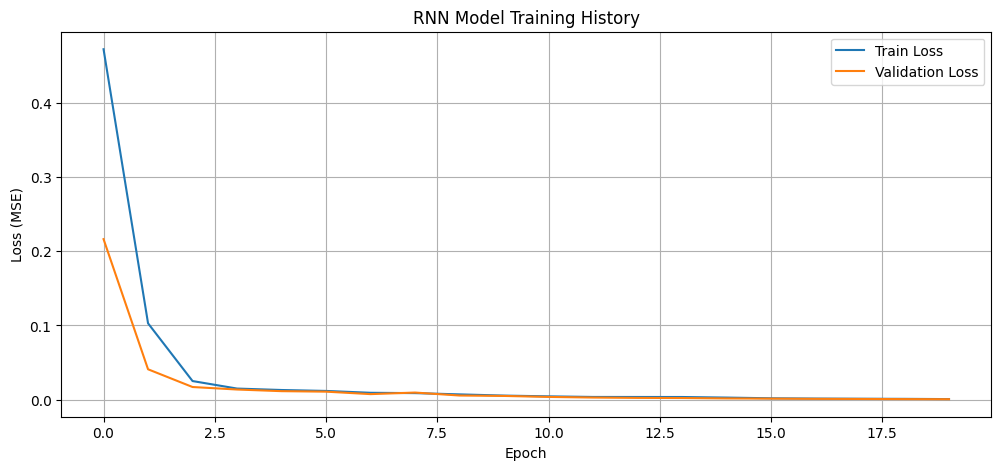

In [56]:
# --- 3. Compile and Train the Model ---
rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training RNN model...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20, # Number of training epochs
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)

print("RNN model training complete.")

# Plot training history
plt.figure(figsize=(12, 5))
plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.title('RNN Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate the RNN Model

Finally, let's evaluate the trained RNN model on the unseen test data and make some predictions to see how well it learned the sequence pattern.

RNN Test Loss (MSE): 0.0007
RNN Test MAE: 0.0203
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


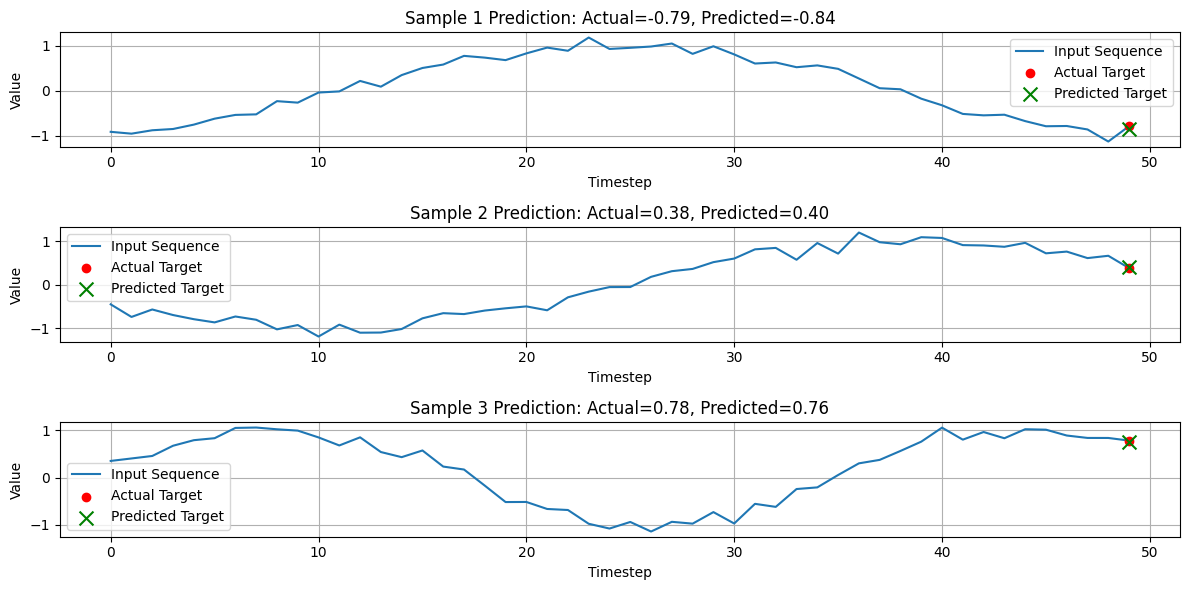

In [57]:
# --- 4. Evaluate the Model ---
loss, mae = rnn_model.evaluate(X_test, y_test, verbose=0)
print(f"RNN Test Loss (MSE): {loss:.4f}")
print(f"RNN Test MAE: {mae:.4f}")

# --- 5. Make Predictions ---
predictions = rnn_model.predict(X_test)

# Visualize some predictions
plt.figure(figsize=(12, 6))
for i in range(3): # Plot first 3 test samples
    plt.subplot(3, 1, i + 1)
    plt.plot(X_test[i, :, 0], label='Input Sequence')
    plt.scatter(timesteps - 1, y_test[i, 0], color='red', zorder=5, label='Actual Target')
    plt.scatter(timesteps - 1, predictions[i, 0], color='green', marker='x', s=100, zorder=5, label='Predicted Target')
    plt.title(f'Sample {i+1} Prediction: Actual={y_test[i, 0]:.2f}, Predicted={predictions[i, 0]:.2f}')
    plt.xlabel('Timestep')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)


Compiling CNN model...
CNN model compiled.

Training CNN model...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 200ms/step - accuracy: 0.9670 - loss: 2.7541 - val_accuracy: 0.5000 - val_loss: 12.3359
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8606 - loss: 2.3359 - val_accuracy: 0.5000 - val_loss: 25.6414
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7878 - loss: 1.7319 - val_accuracy: 0.5000 - val_loss: 20.7992
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7191 - loss: 1.9117 - val_accuracy: 0.5000 - val_loss: 0.6962
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7429 - loss: 0.6523 - val_accuracy: 0.5000 - val_loss: 0.6999
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7429 - loss: 0.6390 - val_accuracy: 0.5000 - val_loss: 0.7044
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7429 - loss: 0.6281 - val_accuracy: 0.5000 - val_loss: 0.7094
Epoch 8/10
163/163 ━━━━━━

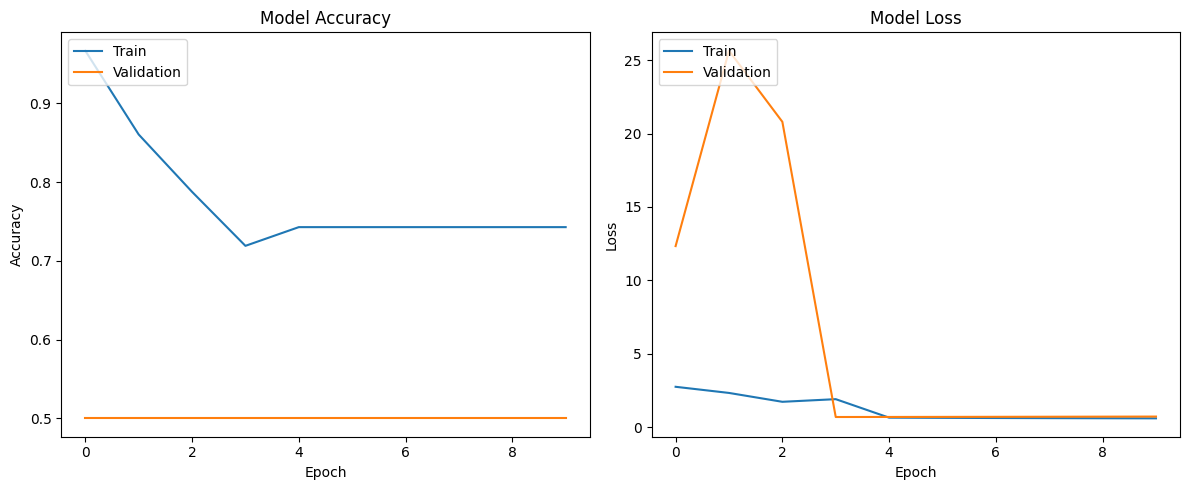

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Define the CNN model architecture (re-defining to ensure it's in scope)
def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        # First Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Second Convolutional Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Third Convolutional Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten the output to feed into a Dense layer
        layers.Flatten(),

        # Dense layers for classification
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Dropout for regularization
        layers.Dense(num_classes, activation='sigmoid') # Output layer for binary classification
    ])
    return model

# Re-define necessary parameters (ensure they are in scope)
IMAGE_SIZE = (128, 128)
input_shape = (*IMAGE_SIZE, 1) # Grayscale images
num_classes = 1 # Binary classification (Pneumonia/Normal)
EPOCHS = 10 # Number of training epochs (can be adjusted)

# Create an instance of the CNN model
model = create_cnn_model(input_shape, num_classes)
model.summary()

# Compile the model
print("\nCompiling CNN model...")
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Suitable for binary classification
    metrics=['accuracy']
)
print("CNN model compiled.")

# --- Training ---
print("\nTraining CNN model...")
history = model.fit(
    train_ds_custom,
    validation_data=val_ds_custom,
    epochs=EPOCHS,
    verbose=1
)
print("CNN model training complete.")

# --- Evaluation ---
print("\nEvaluating model on test data...")
loss, accuracy = model.evaluate(test_ds_custom)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# --- Visualize Training History ---
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


In [25]:
print(f"Contents of the extracted directory '{extract_dir}':")
!ls -R {extract_dir}

Streaming output truncated to the last 5000 lines.
image1_77_png.rf.40aa79c7cf49388b0c85a7fea44ecac0.jpg
image1_77_png.rf.737788e8914549c99d6625dd53947649.jpg
image1_77_png.rf.77f753e3e371ffba460e810d7ef17922.jpg
image1_77_png.rf.ffc78fd2dd54a787faf573ae7446593a.jpg
image1_7817_png.rf.960faf235342d59143645fc760e6442b.jpg
image1_7817_png.rf.bc14d80bef93d856ea1e7de31fe77c85.jpg
image1_7817_png.rf.c068ac7683b97e14e924a756c9d269e7.jpg
image1_782_png.rf.0c2a77d730675bba0c25a6819919e769.jpg
image1_782_png.rf.55fd7afbb62059260d8fca61357bde4c.jpg
image1_782_png.rf.d9992b49e3dc0b3abf638e09862b7a8e.jpg
image1_785_png.rf.2d0a04e292872dc052f8f99623f3e8ee.jpg
image1_785_png.rf.4609b1acf4215ddbc4bbd30c48a7515f.jpg
image1_785_png.rf.7ab04c39d96331cb0a07bda180a4a296.jpg
image1_788_png.rf.2343ea1d06fe5e575fdc174137de3899.jpg
image1_788_png.rf.46c957a23d7486321e267481ce82fb72.jpg
image1_788_png.rf.d61d184a11601a953f3a467398ebfca2.jpg
image1_792_png.rf.2a359597b76c365ffcfa713320a3f666.jpg
image1_792_png.